In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('transactions.csv')

total_rows = len(df)
unique_senders = df['sender_id'].nunique()
unique_receivers = df['receiver_id'].nunique()
total_unique = pd.concat([df['sender_id'], df['receiver_id']]).nunique()

temp_dates = pd.to_datetime(df['date'], format='%d.%m.%Y', errors='coerce')
min_date = temp_dates.min().strftime('%Y-%m-%d')
max_date = temp_dates.max().strftime('%Y-%m-%d')

print(f"Total lines in the file: {total_rows}")
print(f"Data period: с {min_date} по {max_date}")
print(f"Unique senders: {unique_senders}")
print(f"Unique recipients: {unique_receivers}")
print(f"Total unique participants: {total_unique}\n")

print("Top 20 sender (Outgoing turnover)")
top_senders = df.groupby('sender_id')['amount_kzt'].sum().sort_values(ascending=False).head(20)
print(top_senders.apply(lambda x: f"{x:,.2f} KZT")) 

Total lines in the file: 80800
Data period: с 2024-01-01 по 2026-04-30
Unique senders: 6140
Unique recipients: 6099
Total unique participants: 7215

Top 20 sender (Outgoing turnover)
sender_id
720221554469    755,445,096.06 KZT
580811600403    744,599,780.87 KZT
310909691346    718,772,375.01 KZT
170915651329    706,992,420.92 KZT
181226594058    703,369,395.85 KZT
140512557513    686,648,853.40 KZT
401110643824    679,180,502.99 KZT
570328465547    640,561,703.49 KZT
941101594315    636,412,872.28 KZT
460614400792    613,617,114.16 KZT
970913552723    611,845,748.35 KZT
270122476708    611,645,284.69 KZT
371002684702    598,168,975.20 KZT
750125644155    593,509,554.77 KZT
861218496740    587,582,383.82 KZT
100925580902    587,383,007.36 KZT
450815601992    572,590,457.41 KZT
181120401530    571,889,889.08 KZT
280812467978    566,591,658.70 KZT
641104654277    548,233,112.17 KZT
Name: amount_kzt, dtype: object


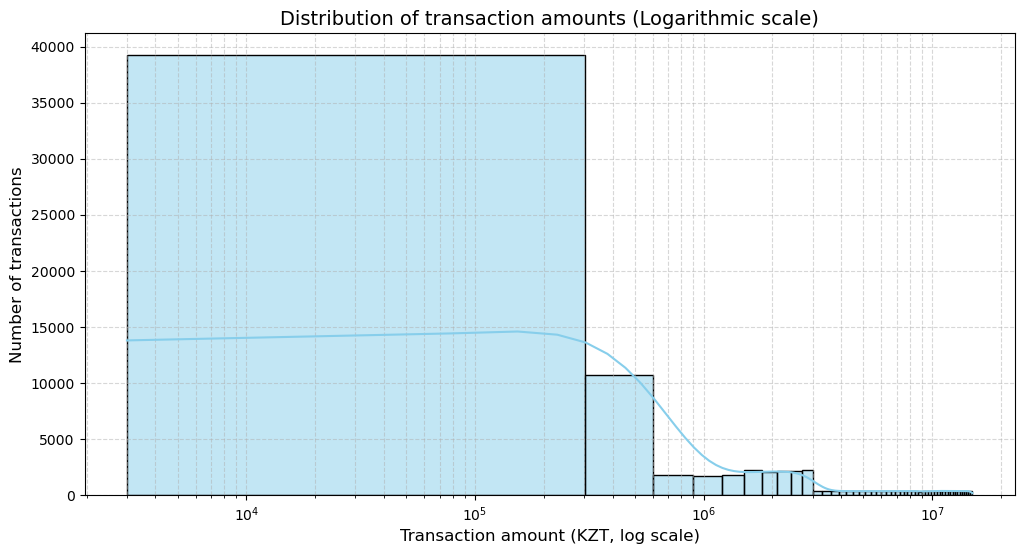

In [3]:
positive_amounts = df[df['amount_kzt'] > 0]['amount_kzt']

plt.figure(figsize=(12, 6))
sns.histplot(positive_amounts, bins=50, kde=True, color='skyblue')

plt.xscale('log') 

plt.title('Distribution of transaction amounts (Logarithmic scale)', fontsize=14)
plt.xlabel('Transaction amount (KZT, log scale)', fontsize=12)
plt.ylabel('Number of transactions', fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

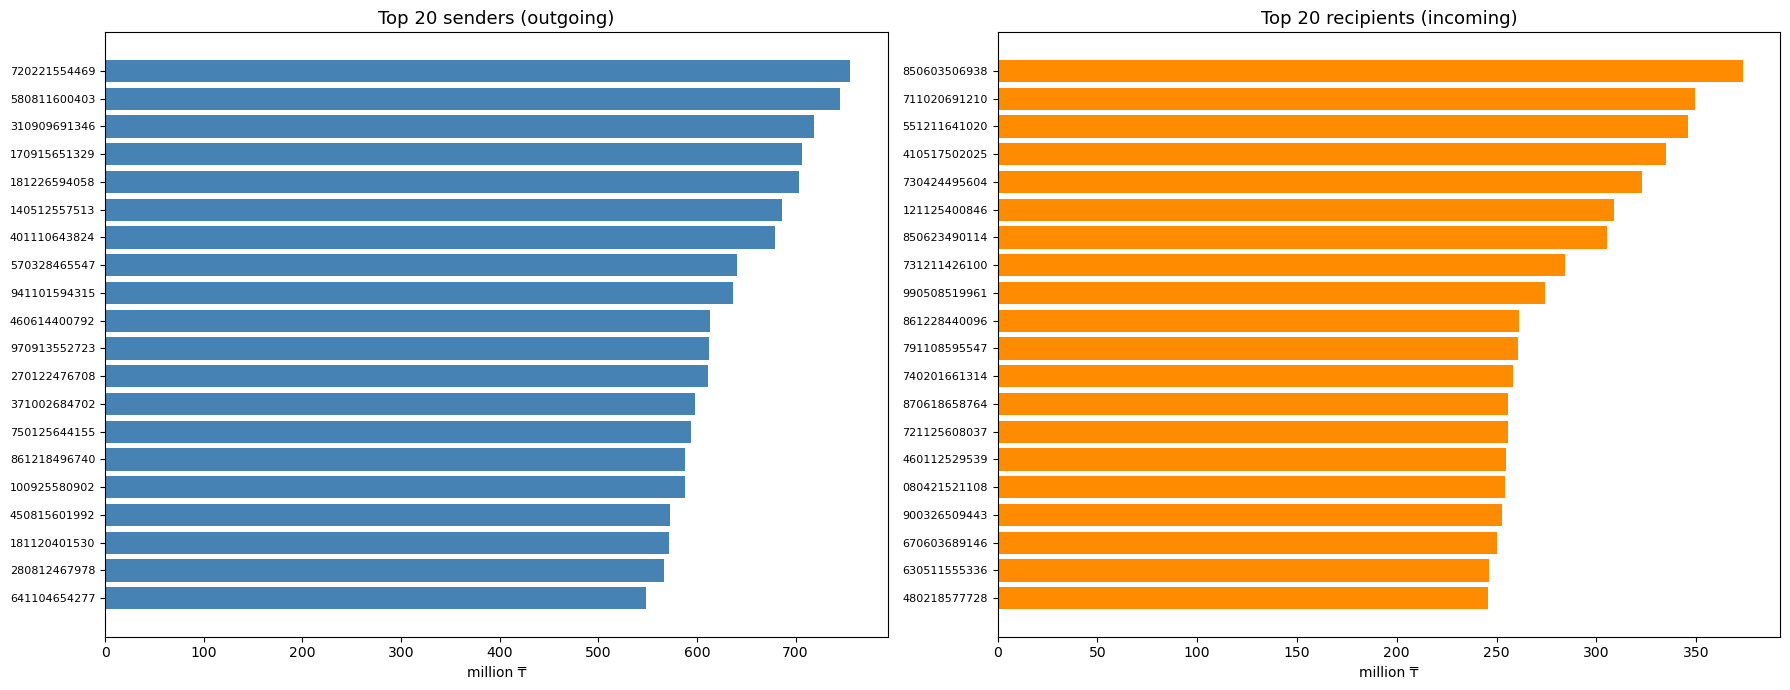

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
 
top_s = df.groupby('sender_id')['amount_kzt'].sum().sort_values(ascending=False).head(20)
top_r = df.groupby('receiver_id')['amount_kzt'].sum().sort_values(ascending=False).head(20)
 
axes[0].barh(range(20), top_s.values[::-1] / 1e6, color='steelblue')
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(top_s.index[::-1], fontsize=8)
axes[0].set_title('Top 20 senders (outgoing)', fontsize=13)
axes[0].set_xlabel('million ₸')
 
axes[1].barh(range(20), top_r.values[::-1] / 1e6, color='darkorange')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(top_r.index[::-1], fontsize=8)
axes[1].set_title('Top 20 recipients (incoming)', fontsize=13)
axes[1].set_xlabel('million ₸')
 
plt.tight_layout()
plt.show()

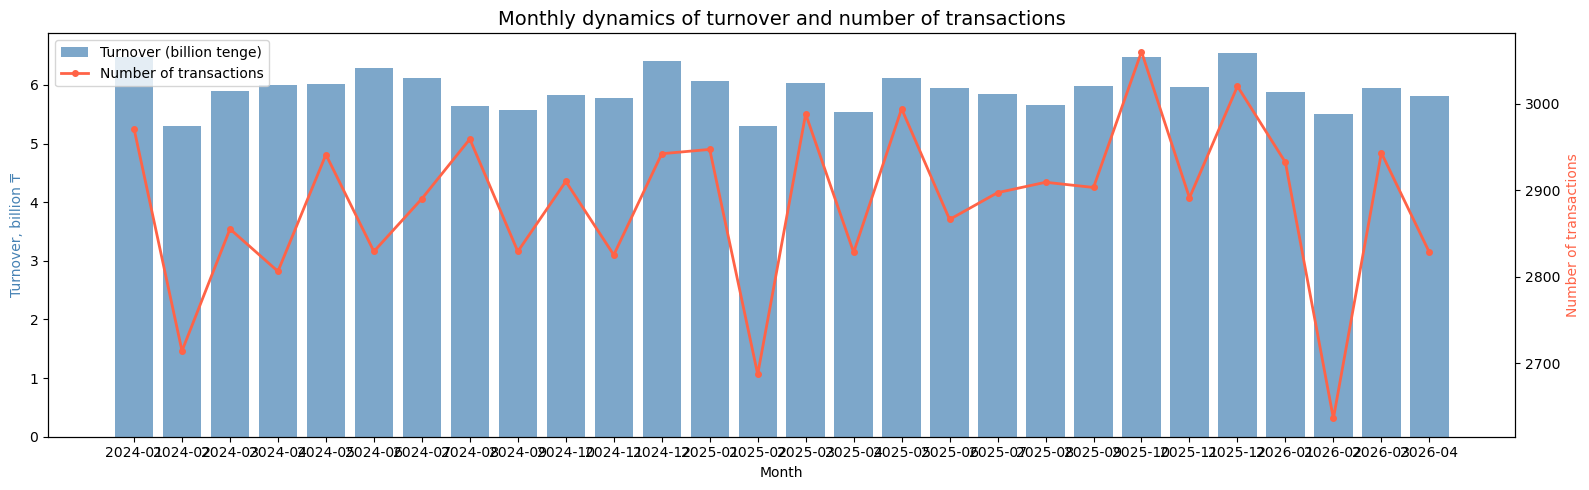

In [7]:
import re
 
def parse_date(d):
    for fmt in ('%Y-%m-%d', '%Y/%m/%d', '%d.%m.%Y', '%d/%m/%Y'):
        try:
            return pd.to_datetime(d, format=fmt)
        except:
            pass
    return pd.NaT
 
df['date_parsed'] = df['date'].apply(parse_date)
df['month'] = df['date_parsed'].dt.to_period('M')
 
monthly = (df.groupby('month')['amount_kzt']
             .agg(total='sum', count='count')
             .reset_index())
monthly['month_str'] = monthly['month'].astype(str)
 
fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()
 
ax1.bar(monthly['month_str'], monthly['total'] / 1e9, color='steelblue', alpha=0.7, label='Turnover (billion tenge)')
ax2.plot(monthly['month_str'], monthly['count'], color='tomato', linewidth=2, marker='o', markersize=4, label='Number of transactions')
 
ax1.set_xlabel('Month')
ax1.set_ylabel('Turnover, billion ₸', color='steelblue')
ax2.set_ylabel('Number of transactions', color='tomato')
ax1.set_title('Monthly dynamics of turnover and number of transactions', fontsize=14)
plt.xticks(rotation=45, ha='right')
 
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()

In [9]:
print("=" * 65)
print("Anomaly 1: Negative transaction amounts")
neg = df[df['amount_kzt'] < 0]
print(f"  Found: {len(neg)} lines ({len(neg)/len(df)*100:.2f}%)")
print(f"  Minimum value: {neg['amount_kzt'].min():,.2f} ₸")
print("  Example lines:")
print(neg[['sender_id','receiver_id','date','amount_kzt','description']].head(3).to_string(index=False))
print()
print(" -> Real payment transactions cannot have a negative amount.")
print("    Possible reasons: reversal, input error, payment return.")
 
print()
print("=" * 65)
print("Anomaly 2: Incorrect BIN/IIN (not 12 digits)")
bad_s = df[df['sender_id'].str.len() != 12]
bad_r = df[df['receiver_id'].str.len() != 12]
print(f"  Incorrect sender_id:   {len(bad_s)} ({len(bad_s)/len(df)*100:.2f}%)")
print(f"  Incorrect receiver_id: {len(bad_r)} ({len(bad_r)/len(df)*100:.2f}%)")
print("  Examples of bad IDs:", df['sender_id'][df['sender_id'].str.len() != 12].head(5).tolist())
print()
print(" -> BIN/IIN in Kazakhstan is strictly 12-digit. Extra or")
print("    missing characters are typos when entering data.")
 
print()
print("=" * 65)
print("Anomaly 3: Four different date formats in one field")
formats = {
    'ISO  YYYY-MM-DD': df['date'].str.match(r'^\d{4}-\d{2}-\d{2}$').sum(),
    'YYYY/MM/DD':      df['date'].str.match(r'^\d{4}/\d{2}/\d{2}$').sum(),
    'DD.MM.YYYY':      df['date'].str.match(r'^\d{2}\.\d{2}\.\d{4}$').sum(),
    'DD/MM/YYYY':      df['date'].str.match(r'^\d{2}/\d{2}/\d{4}$').sum(),
}
for k, v in formats.items():
    print(f"  {k}: {v:,} строк")
print()
print(" -> Mixed formats make direct sorting impossible")
print("    and comparison of dates without prior normalization.")
 

Anomaly 1: Negative transaction amounts
  Found: 384 lines (0.48%)
  Minimum value: -14,933,931.84 ₸
  Example lines:
   sender_id   receiver_id       date   amount_kzt                                  description
960406579569  731211426100 2024-05-01    -27772.65   Услуги по разработке мобильного приложения
641026292042  051019487730 2025-06-25    -10663.11    Кирпич керамический полнотелый — 10000 шт
540813406186 9411269439263 03/03/2026 -14833275.78 Электроэнергия за февраль 2025, договор №455

 -> Real payment transactions cannot have a negative amount.
    Possible reasons: reversal, input error, payment return.

Anomaly 2: Incorrect BIN/IIN (not 12 digits)
  Incorrect sender_id:   813 (1.01%)
  Incorrect receiver_id: 776 (0.96%)
  Examples of bad IDs: ['401014-640060', '26121571325', '1609183 07027', '21021943130', '6207055637 46']

 -> BIN/IIN in Kazakhstan is strictly 12-digit. Extra or
    missing characters are typos when entering data.

Anomaly 3: Four different date formats

In [11]:
rows_before = len(df)
 
df['date'] = df['date'].apply(parse_date)
 
nat_count = df['date'].isna().sum()
print(f"Date not recognized (NaT): {nat_count}")
print(f"Post-normalization period: {df['date'].min().date()} — {df['date'].max().date()}")
print(f"\nExample of normalized dates:")
print(df['date'].head(5))

Date not recognized (NaT): 0
Post-normalization period: 2024-01-01 — 2026-04-30

Example of normalized dates:
0   2024-10-05
1   2025-07-29
2   2025-05-17
3   2024-02-08
4   2024-10-20
Name: date, dtype: datetime64[ns]


In [15]:
WEIGHTS1 = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
WEIGHTS2 = [3, 4, 5, 6, 7, 8, 9, 10, 11, 1,  2]
 
def luhn_kz(bin_str: str) -> bool:
    """
    Kazakhstan BIN/IIN checksum.
    Step 1: Multiply the first 11 digits by WEIGHTS1, sum them, and take the modifier 11.
    Step 2: If the result equals 10, repeat with WEIGHTS2.
    The result must match the 12th digit (the checksum).
    """
    if not re.match(r'^\d{12}$', str(bin_str)):
        return False
    digits = [int(c) for c in bin_str]
    s = sum(w * d for w, d in zip(WEIGHTS1, digits[:11])) % 11
    if s == 10:
        s = sum(w * d for w, d in zip(WEIGHTS2, digits[:11])) % 11
    return s == digits[11]
 
df['sender_valid']   = df['sender_id'].apply(luhn_kz)
df['receiver_valid'] = df['receiver_id'].apply(luhn_kz)
 
print(f"Valid sender_id:   {df['sender_valid'].sum():,}  ({df['sender_valid'].mean()*100:.1f}%)")
print(f"Invalid sender_id: {(~df['sender_valid']).sum():,} ({(~df['sender_valid']).mean()*100:.1f}%)")
print()
print(f"Valid receiver_id:   {df['receiver_valid'].sum():,}  ({df['receiver_valid'].mean()*100:.1f}%)")
print(f"Invalid receiver_id: {(~df['receiver_valid']).sum():,} ({(~df['receiver_valid']).mean()*100:.1f}%)")

Valid sender_id:   79,610  (98.5%)
Invalid sender_id: 1,190 (1.5%)

Valid receiver_id:   79,674  (98.6%)
Invalid receiver_id: 1,126 (1.4%)


In [17]:
rows_before = len(df)
 

df = df.drop_duplicates(subset=['sender_id', 'receiver_id', 'date', 'description', 'doc_type'])
 
rows_after = len(df)
print(f"Lines to:              {rows_before:,}")
print(f"Duplicates removed:    {rows_before - rows_after:,}")
print(f"Lines after:           {rows_after:,}")

Lines to:              80,800
Duplicates removed:    800
Lines after:           80,000


In [21]:
summary = pd.DataFrame({
    'Metric': [
        'Total rows',
        'After removing duplicates',
        'Date formats',
        'Valid sender_ids',
        'Valid receiver_ids',
        'Gaps in description',
        'Negative amounts',
    ],
    'Before': [
        '80 800',
        '—',
        '4 different formats',
        f"{(df['sender_id'].str.len()==12).mean()*100:.1f}% (only length)",
        f"{(df['receiver_id'].str.len()==12).mean()*100:.1f}% (only length)",
        f"{df['description'].isna().mean()*100:.1f}%",
        '384 lines',
    ],
    'After': [
        '80 800',
        f'{rows_after:,}',
        'ISO 8601 (YYYY-MM-DD)',
        f"{df['sender_valid'].mean()*100:.1f}%",
        f"{df['receiver_valid'].mean()*100:.1f}%",
        f"{df['description'].isna().mean()*100:.1f}%",
        '384 (flagged, not removed)',
    ],
})
summary

,Metric,Before,After
0,Total rows,80 800,80 800
1,After removing duplicates,—,"80,000"
2,Date formats,4 different formats,ISO 8601 (YYYY-MM-DD)
3,Valid sender_ids,99.0% (only length),98.5%
4,Valid receiver_ids,99.0% (only length),98.6%
5,Gaps in description,1.0%,1.0%
6,Negative amounts,384 lines,"384 (flagged, not removed)"


In [33]:
import sqlite3

DB_PATH = 'transactions.db'

df_sql = df.copy()
df_sql = df_sql.drop(columns=['month', 'date_parsed'], errors='ignore')
df_sql['date']           = df_sql['date'].dt.strftime('%Y-%m-%d')
df_sql['sender_valid']   = df_sql['sender_valid'].astype(int)
df_sql['receiver_valid'] = df_sql['receiver_valid'].astype(int)

conn = sqlite3.connect(DB_PATH)
df_sql.to_sql('transactions', conn, if_exists='replace', index=False)  

count = conn.execute('SELECT COUNT(*) FROM transactions').fetchone()[0]
print(f"DB created: {DB_PATH}")
print(f"Rows in table: {count:,}")

DB created: transactions.db
Rows in table: 80,000


In [35]:
q1 = """
SELECT
    sender_id,
    receiver_id,
    COUNT(*)                        AS tx_count,
    ROUND(SUM(amount_kzt), 2)       AS total_kzt,
    ROUND(AVG(amount_kzt), 2)       AS avg_kzt
FROM transactions
GROUP BY sender_id, receiver_id
ORDER BY total_kzt DESC
LIMIT 10
"""
pd.read_sql(q1, conn)

,sender_id,receiver_id,tx_count,total_kzt,avg_kzt
0,960819662090,711020691210,106,2.975443e+08,2807021.73
1,271023534832,850603506938,94,2.564739e+08,2728445.53
2,310405616795,551211641020,105,2.452937e+08,2336130.74
3,640522553440,730424495604,88,2.368354e+08,2691311.92
4,151008697404,740201661314,90,2.296884e+08,2552093.39
5,550624571494,850623490114,82,2.294590e+08,2798280.16
6,760616418322,410517502025,79,2.125045e+08,2689930.24
7,861121409930,121125400846,87,2.042040e+08,2347172.41
8,680213490446,900326509443,88,2.020552e+08,2296081.61
9,960406579569,221201693852,89,1.864100e+08,2094494.30


In [37]:
q2 = """
WITH monthly AS (
    SELECT
        sender_id,
        STRFTIME('%Y-%m', date)     AS month,
        SUM(amount_kzt)             AS monthly_total
    FROM transactions
    GROUP BY sender_id, month
)
SELECT
    sender_id,
    month,
    ROUND(monthly_total, 2)         AS monthly_total,
    ROUND(
        SUM(monthly_total) OVER (
            PARTITION BY sender_id
            ORDER BY month
            ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
        ), 2
    )                               AS rolling_3m_sum
FROM monthly
ORDER BY sender_id, month
LIMIT 30
"""
pd.read_sql(q2, conn)
 

,sender_id,month,monthly_total,rolling_3m_sum
0,000 424074882,2024-08,869214.84,869214.84
1,000103385227,2024-03,55257.61,55257.61
2,000103385227,2024-09,144124.44,199382.05
3,000103385227,2024-11,23653.16,223035.21
4,000103385227,2025-01,10440.91,178218.51
5,000103385227,2025-03,2745540.03,2779634.10
6,000103385227,2025-08,68892.16,2824873.10
7,000103385227,2025-12,4008535.20,6822967.39
8,000103385227,2026-02,618046.75,4695474.11
9,000106-497273,2026-01,140243.35,140243.35


In [41]:
q3 = """
WITH pair AS (
    SELECT receiver_id, sender_id, SUM(amount_kzt) AS pair_total
    FROM transactions
    WHERE amount_kzt > 0 AND receiver_valid = 1 AND sender_valid = 1
    GROUP BY receiver_id, sender_id
),
total AS (
    SELECT receiver_id, SUM(amount_kzt) AS grand_total
    FROM transactions
    WHERE amount_kzt > 0 AND receiver_valid = 1
    GROUP BY receiver_id
)
SELECT
    p.receiver_id,
    p.sender_id AS dominant_sender,
    ROUND(p.pair_total, 2) AS pair_total_kzt,
    ROUND(t.grand_total, 2) AS grand_total_kzt,
    ROUND(p.pair_total * 100.0 / t.grand_total, 1) AS share_pct
FROM pair p
JOIN total t ON p.receiver_id = t.receiver_id
WHERE p.pair_total * 1.0 / t.grand_total > 0.7
  AND t.grand_total > 1000000
ORDER BY share_pct DESC
LIMIT 20
"""
result = pd.read_sql(q3, conn)
print(f"Counterparties with incoming concentration >70%: {len(result)}")
result

Counterparties with incoming concentration >70%: 20


,receiver_id,dominant_sender,pair_total_kzt,grand_total_kzt,share_pct
0,771020553470,720903078056,14186721.01,14648530.82,96.8
1,260321585703,090504618028,10519842.77,10955384.83,96.0
2,040603497571,260321585703,2038836.16,2126576.97,95.9
3,361106421557,610308598441,12553950.56,13158978.96,95.4
4,441021449949,140512557513,14517668.14,15254626.49,95.2
5,430317587625,220308652100,13432475.10,14211021.60,94.5
6,250708477163,650519548083,2281828.57,2420712.24,94.3
7,110718590440,740208045302,9023511.64,9575701.83,94.2
8,011220256228,350527595756,10016636.89,10688963.30,93.7
9,530111482976,530801225985,13612723.64,14662872.13,92.8


In [43]:
conn.close()
print("Done. SQLite connection closed.")

Done. SQLite connection closed.
